In [28]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [13]:
#creating the data 
import csv
data = []
with open('DailyDelhiClimateTrain.csv', newline='') as csvfile:
    temp_reader = csv.DictReader(csvfile)
    for row in temp_reader:
        data.append(row['meantemp'])
# len(data)
data_size = 101
data_train = [float(x) for x in data[:101]]
data_train

[10.0,
 7.4,
 7.166666666666667,
 8.666666666666666,
 6.0,
 7.0,
 7.0,
 8.857142857142858,
 14.0,
 11.0,
 15.714285714285714,
 14.0,
 15.833333333333334,
 12.833333333333334,
 14.714285714285714,
 13.833333333333334,
 16.5,
 13.833333333333334,
 12.5,
 11.285714285714286,
 11.2,
 9.5,
 14.0,
 13.833333333333334,
 12.25,
 12.666666666666666,
 12.857142857142858,
 14.833333333333334,
 14.125,
 14.714285714285714,
 16.2,
 16.0,
 16.285714285714285,
 18.0,
 17.428571428571427,
 16.625,
 16.666666666666668,
 15.6,
 14.0,
 15.428571428571429,
 15.25,
 15.875,
 15.333333333333334,
 16.285714285714285,
 17.333333333333332,
 19.166666666666668,
 14.428571428571429,
 13.666666666666666,
 15.6,
 15.857142857142858,
 17.714285714285715,
 20.0,
 20.5,
 17.428571428571427,
 16.857142857142858,
 16.875,
 17.857142857142858,
 20.8,
 19.428571428571427,
 17.333333333333332,
 19.0,
 19.333333333333332,
 17.6,
 20.875,
 20.857142857142858,
 23.428571428571427,
 24.166666666666668,
 25.428571428571427,
 2

In [20]:
import numpy as np
import torch

data_train = np.array(data_train, dtype=np.float32)

# normalize
mean = data_train.mean()
std  = data_train.std()
data_norm = (data_train - mean) / std

# make sequences
SEQ_LEN = 10

def make_sequences(data, seq_len):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        Y.append(data[i + seq_len])
    X = torch.tensor(np.array(X)).unsqueeze(-1)  # (91, 10, 1)
    Y = torch.tensor(np.array(Y)).unsqueeze(-1)  # (91, 1)
    return X, Y

X, Y = make_sequences(data_norm, SEQ_LEN)
print(f"X: {X.shape}, Y: {Y.shape}")

X: torch.Size([91, 10, 1]), Y: torch.Size([91, 1])


In [21]:
# lstm model 
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # weights for input x  (one for each gate)
        self.Wi = nn.Linear(input_size, hidden_size)  # input gate
        self.Wf = nn.Linear(input_size, hidden_size)  # forget gate
        self.Wg = nn.Linear(input_size, hidden_size)  # candidate
        self.Wo = nn.Linear(input_size, hidden_size)  # output gate
        
        # weights for previous hidden state (one for each gate)
        self.Ui = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Uf = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Ug = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Uo = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x, h_prev, c_prev):
        i = torch.sigmoid(self.Wi(x) + self.Ui(h_prev))  # input gate
        f = torch.sigmoid(self.Wf(x) + self.Uf(h_prev))  # forget gate
        g = torch.tanh(self.Wg(x) + self.Ug(h_prev))     # candidate cell
        o = torch.sigmoid(self.Wo(x) + self.Uo(h_prev))  # output gate
        
        c = f * c_prev + i * g   # update cell state
        h = o * torch.tanh(c)    # update hidden state
        
        return h, c

In [22]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = LSTMCell(input_size, hidden_size)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch = x.shape[0]
        
        # start with zero hidden and cell state
        h = torch.zeros(batch, self.hidden_size)
        c = torch.zeros(batch, self.hidden_size)

        # loop over each timestep manually
        for t in range(x.shape[1]):    # x.shape[1] = SEQ_LEN = 10
            h, c = self.cell(x[:, t, :], h, c)
            #              ↑
            #        one day at a time

        # after all timesteps, h summarizes the whole sequence
        return self.fc(h)

model = LSTMModel(hidden_size=16)
print(f"Total params: {sum(p.numel() for p in model.parameters())}")

Total params: 1169


Epoch 50/300  loss: 0.0886
Epoch 100/300  loss: 0.0840
Epoch 150/300  loss: 0.0755
Epoch 200/300  loss: 0.0639
Epoch 250/300  loss: 0.0575
Epoch 300/300  loss: 0.0484


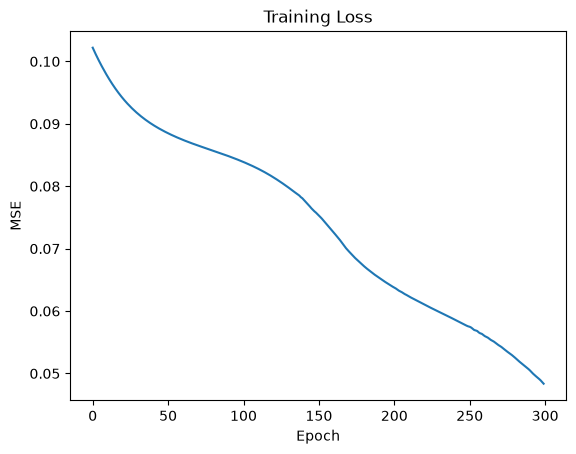

In [29]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

losses = []

for epoch in range(300):
    model.train()
    pred = model(X)           # forward pass
    loss = loss_fn(pred, Y)   # compare prediction vs actual
    
    optimizer.zero_grad()     # clear old gradients
    loss.backward()           # backprop through time
    optimizer.step()          # update weights
    
    losses.append(loss.item())
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/300  loss: {loss.item():.4f}")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

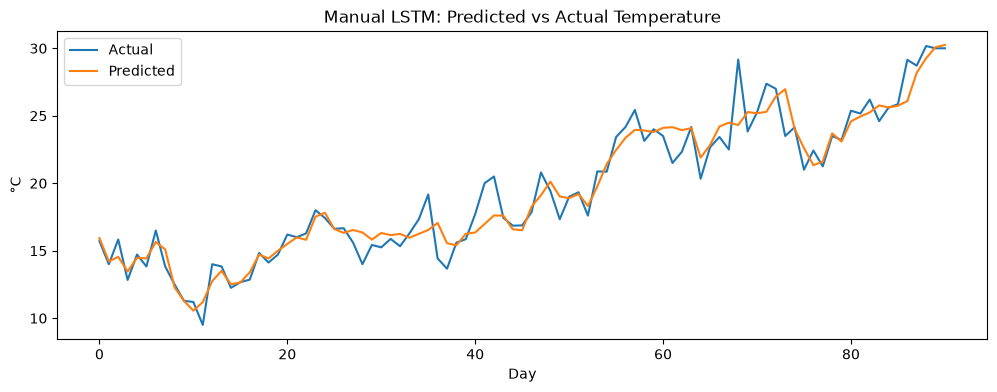

RMSE: 1.28 °C


In [30]:
model.eval()
with torch.no_grad():
    pred_norm = model(X).squeeze().numpy()

# denormalize
pred_temps   = pred_norm * std + mean
actual_temps = Y.squeeze().numpy() * std + mean

plt.figure(figsize=(12, 4))
plt.plot(actual_temps, label='Actual')
plt.plot(pred_temps,   label='Predicted')
plt.title("Manual LSTM: Predicted vs Actual Temperature")
plt.xlabel("Day")
plt.ylabel("°C")
plt.legend()
plt.show()

rmse = np.sqrt(np.mean((pred_temps - actual_temps)**2))
print(f"RMSE: {rmse:.2f} °C")